# Risk Detection 



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv("edu_growth_cleaned.csv")

## Feature engineering

In [28]:
subject_attendance_cols = [
    "coa_attendance_pct",
    "maths4_attendance_pct",
    "dstl_attendance_pct",
    "ds_attendance_pct",
    "python_attendance_pct",
    "cyber_attendance_pct"]
df["subject_attendance_avg"] = df[subject_attendance_cols].mean

In [10]:
lab_attendance_cols = [
    "lab_ds_attendance_pct",
    "lab_python_attendance_pct",
    "lab_coa_attendance_pct",
    "lab_cyber_attendance_pct"]
df["lab_attendance_avg"] = df[lab_attendance_cols].mean

In [16]:
assignment_delay_cols = [
    "coa_assignment_delay_hours",
    "maths4_assignment_delay_hours",
    "dstl_assignment_delay_hours",
    "ds_assignment_delay_hours",
    "python_assignment_delay_hours",
    "cyber_assignment_delay_hours"]
df["avg_assignment_delay_hours"] = df[assignment_delay_cols].mean

In [15]:
assignment_score_cols = [
    "coa_assignment_score",
    "maths4_assignment_score",
    "dstl_assignment_score",
    "ds_assignment_score",
    "python_assignment_score",
    "cyber_assignment_score"]
df["avg_assignment_score"] = df[assignment_score_cols].mean

In [17]:
quiz_cols = [
    "coa_quiz_score",
    "maths4_quiz_score",
    "dstl_quiz_score",
    "ds_quiz_score",
    "python_quiz_score",
    "cyber_quiz_score"]
df["avg_quiz_score"] = df[quiz_cols].mean

In [18]:
put_cols = [
    "coa_put_marks",
    "maths4_put_marks",
    "dstl_put_marks",
    "ds_put_marks",
    "python_put_marks",
    "cyber_put_marks"]
df["put_avg"] = df[put_cols].mean

In [19]:
st1_cols = [
    "coa_st1_marks",
    "maths4_st1_marks",
    "dstl_st1_marks",
    "ds_st1_marks",
    "python_st1_marks",
    "cyber_st1_marks"]

st2_cols = [
    "coa_st2_marks",
    "maths4_st2_marks",
    "dstl_st2_marks",
    "ds_st2_marks",
    "python_st2_marks",
    "cyber_st2_marks"]

df["st1_avg"] = df[st1_cols].mean
df["st2_avg"] = df[st2_cols].mean

C:\Users\Suhani\AppData\Local\Temp\ipykernel_792\3696024485.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["st1_avg"] = df[st1_cols].mean
C:\Users\Suhani\AppData\Local\Temp\ipykernel_792\3696024485.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["st2_avg"] = df[st2_cols].mean


In [20]:
lab_execution_cols = [
    "lab_ds_execution_score",
    "lab_python_execution_score",
    "lab_coa_execution_score",
    "lab_cyber_execution_score"]
df["avg_lab_execution"] = df[lab_execution_cols].mean(axis=1)

C:\Users\Suhani\AppData\Local\Temp\ipykernel_792\1522318853.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["avg_lab_execution"] = df[lab_execution_cols].mean(axis=1)


In [21]:
lab_viva_cols = [
    "lab_ds_viva_score",
    "lab_python_viva_score",
    "lab_coa_viva_score",
    "lab_cyber_viva_score"]
df["avg_lab_viva"] = df[lab_viva_cols].mean(axis=1)

C:\Users\Suhani\AppData\Local\Temp\ipykernel_792\1798987887.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["avg_lab_viva"] = df[lab_viva_cols].mean(axis=1)


In [32]:
lab_delay_cols = [
    "lab_ds_submission_delay_hours",
    "lab_python_submission_delay_hours",
    "lab_coa_submission_delay_hours",
    "lab_cyber_submission_delay_hours"]
df["avg_lab_delay_hours"] = df[lab_delay_cols].mean(axis=1)

In [46]:
cols = ["st1_avg", "st2_avg", "subject_attendance_avg", "lab_attendance_avg", "avg_assignment_delay_hours", "avg_assignment_score", "avg_quiz_score", "put_avg", "avg_lab_execution", "avg_lab_viva", "avg_lab_delay_hours"]
for col in cols:
    df[col] = pd.to_numeric(df[col])

In [47]:
df[["st1_avg", "st2_avg", "subject_attendance_avg", "lab_attendance_avg", "avg_assignment_delay_hours", "avg_assignment_score", "avg_quiz_score", "put_avg", "avg_lab_execution", "avg_lab_viva", "avg_lab_delay_hours"]].dtypes


st1_avg                       float64
st2_avg                       float64
subject_attendance_avg        float64
lab_attendance_avg            float64
avg_assignment_delay_hours    float64
avg_assignment_score          float64
avg_quiz_score                float64
put_avg                       float64
avg_lab_execution             float64
avg_lab_viva                  float64
avg_lab_delay_hours           float64
dtype: object

In [81]:
df["risk_score"] = (
    (df["overall_attendance_pct"] < 75).astype(int)
    + (df["st1_avg"] < 17).astype(int)
    + (df["st2_avg"] < 27).astype(int)
    + (df["avg_assignment_delay_hours"] > 72).astype(int)
    + (df["previous_cgpa"] < 6).astype(int)
    + (df["put_avg"] < 33).astype(int)
)

### Target column

In [82]:
df["risk_flag"] = (df["risk_score"] >= 2).astype(int)

In [ ]:
risk_features = [
    "avg_assignment_score",
    "avg_quiz_score",
    "avg_unit_score",
    "subject_attendance_avg",
    "avg_lab_execution",
    "avg_lab_viva",
    "avg_lab_delay_hours",
    "medical_leave_days"
]

In [84]:
X = df[risk_features]
y = df["risk_flag"]

In [85]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [86]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)

c:\Users\Suhani\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1211: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\Suhani\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1216: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\Suhani\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1240: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


## LOGISTIC REGRESSION

In [87]:
print("Missing values:")
print(np.isnan(X_train).sum())

print("\nInfinite values:")
print(np.isinf(X_train).sum())

Missing values:
260400

Infinite values:
0


In [89]:
X_train = np.nan_to_num(X_train, nan=0)
X_test = np.nan_to_num(X_test, nan=0)

In [91]:
from sklearn.linear_model import LogisticRegression
lr_model= LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [92]:
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

In [93]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,)
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_prob))




Logistic Regression Results
Accuracy: 0.9589247311827958
Precision: 0.8175853018372703
Recall: 0.7193995381062356
F1 Score: 0.7653562653562653
ROC-AUC: 0.9832015853569708


In [94]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, lr_pred)
cm

array([[8295,  139],
       [ 243,  623]])

Text(0.5, 1.0, 'LR-Confusion Matrix')

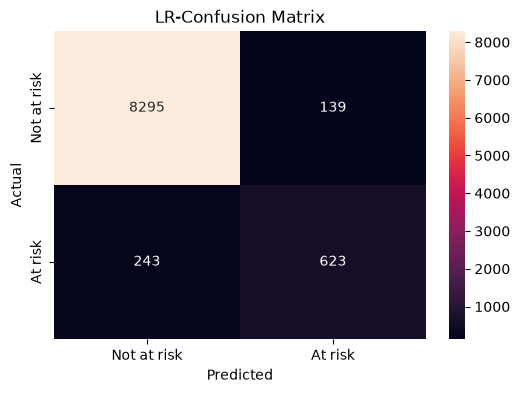

In [95]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Not at risk", "At risk"], yticklabels=["Not at risk", "At risk"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LR-Confusion Matrix")

The Logistic Regression model performed well, with 93.72% accuracy and 97.42% ROC-AUC. It achieved 80.14% precision, 75% recall, and 77.49% F1-score. Overall, the model can effectively identify at-risk students, but it can be further improved to detect more risk cases.

## XGBOOST

In [76]:
from xgboost import XGBClassifier

In [77]:
xgb_model = XGBClassifier(n_estimators=200, max_depth=4, random_state=42)

In [79]:
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [80]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,)

print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1 Score:", f1_score(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_prob))



Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0
